In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\User\Desktop\water\data\clean_water_stats.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'id', 'date_insert', 'year', 'month', 'day', 'hour',
       'sensor_id', 'lat', 'lng', 'wtempV_°C',
       'conductivity_of_solution_ mS_cm', 'oxidation_reduction_potential_ mV',
       'total_suspended_solids_mg_L', 'turbidity_NTU',
       'dissolved_oxygen_concentration _ppm',
       'dissolved_oxygen_concentration_mg_L', 'oxygen_saturation_%',
       'salinity_ppt', 'dissolved_solids _ppm'],
      dtype='object')

In [4]:
# Define feature groups (excluding wtemp)
features_to_scale = [
    'conductivity_of_solution_ mS_cm', 
    'oxidation_reduction_potential_ mV', 
    'oxygen_saturation_%'
]
turbidity_col = 'turbidity_NTU'
sensor_id_col = 'sensor_id'  # Replace with your actual column name if different

# Set how heavily to prioritize turbidity over other features
TURBIDITY_WEIGHT = 2.5

# List to collect processed dataframes
processed_sensor_dfs = []

In [5]:
unique_sensors = df[sensor_id_col].unique()

for sensor in unique_sensors:
    # Isolate data for a single sensor
    sensor_df = df[df[sensor_id_col] == sensor].copy()
    
    # Skip sensors with insufficient data to form 3 clusters
    if len(sensor_df) < 3:
        continue
        
    scaler = StandardScaler()
    
    # Scale the 3 base features
    scaled_matrix = scaler.fit_transform(sensor_df[features_to_scale])
    df_scaled = pd.DataFrame(scaled_matrix, columns=features_to_scale, index=sensor_df.index)
    
    # Scale and weight turbidity separately
    scaled_turbidity = scaler.fit_transform(sensor_df[[turbidity_col]])
    df_scaled[turbidity_col] = scaled_turbidity * TURBIDITY_WEIGHT
    
    # Run K-Means directly on all 4 scaled columns
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)
    
    sensor_df['temp_cluster'] = cluster_labels
    
    # Calculate average turbidity per cluster and sort (lowest to highest)
    turbidity_means = sensor_df.groupby('temp_cluster')[turbidity_col].mean().sort_values()
    
    # Map clusters explicitly by their sorted turbidity index position
    label_mapping = {
        turbidity_means.index[0]: 'Ok',      # Lowest average turbidity
        turbidity_means.index[1]: 'Medium',  # Middle average turbidity
        turbidity_means.index[2]: 'Danger'   # Highest average turbidity
    }
    
    # Map the text labels and clean up
    sensor_df['Water_Quality_Label'] = sensor_df['temp_cluster'].map(label_mapping)
    sensor_df.drop(columns=['temp_cluster'], inplace=True)
    
    processed_sensor_dfs.append(sensor_df)

# Combine everything back into your master training dataset
final_training_df = pd.concat(processed_sensor_dfs, axis=0)

In [6]:
# Show how many rows fall into each class across the city
print("--- Overall Label Distribution ---")
print(final_training_df['Water_Quality_Label'].value_counts())

# Show a quick profile to confirm 'Danger' has the highest turbidity
print("\n--- Feature Averages by Quality Label ---")
profile_cols = [turbidity_col] + features_to_scale
print(final_training_df.groupby('Water_Quality_Label')[profile_cols].mean())

--- Overall Label Distribution ---
Water_Quality_Label
Medium    7782
Ok        5404
Danger    4771
Name: count, dtype: int64

--- Feature Averages by Quality Label ---
                     turbidity_NTU  conductivity_of_solution_ mS_cm  \
Water_Quality_Label                                                   
Danger                  388.102007                     52967.925049   
Medium                  171.460275                     50472.081973   
Ok                       44.472432                     52277.520955   

                     oxidation_reduction_potential_ mV  oxygen_saturation_%  
Water_Quality_Label                                                          
Danger                                      113.753141            70.473777  
Medium                                      150.843236            64.993345  
Ok                                          163.101102            58.776345  


C:\Users\User\AppData\Local\Temp\ipykernel_4912\3157997501.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_4912\3157997501.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_4912\3157997501.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_4912\3157997501.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

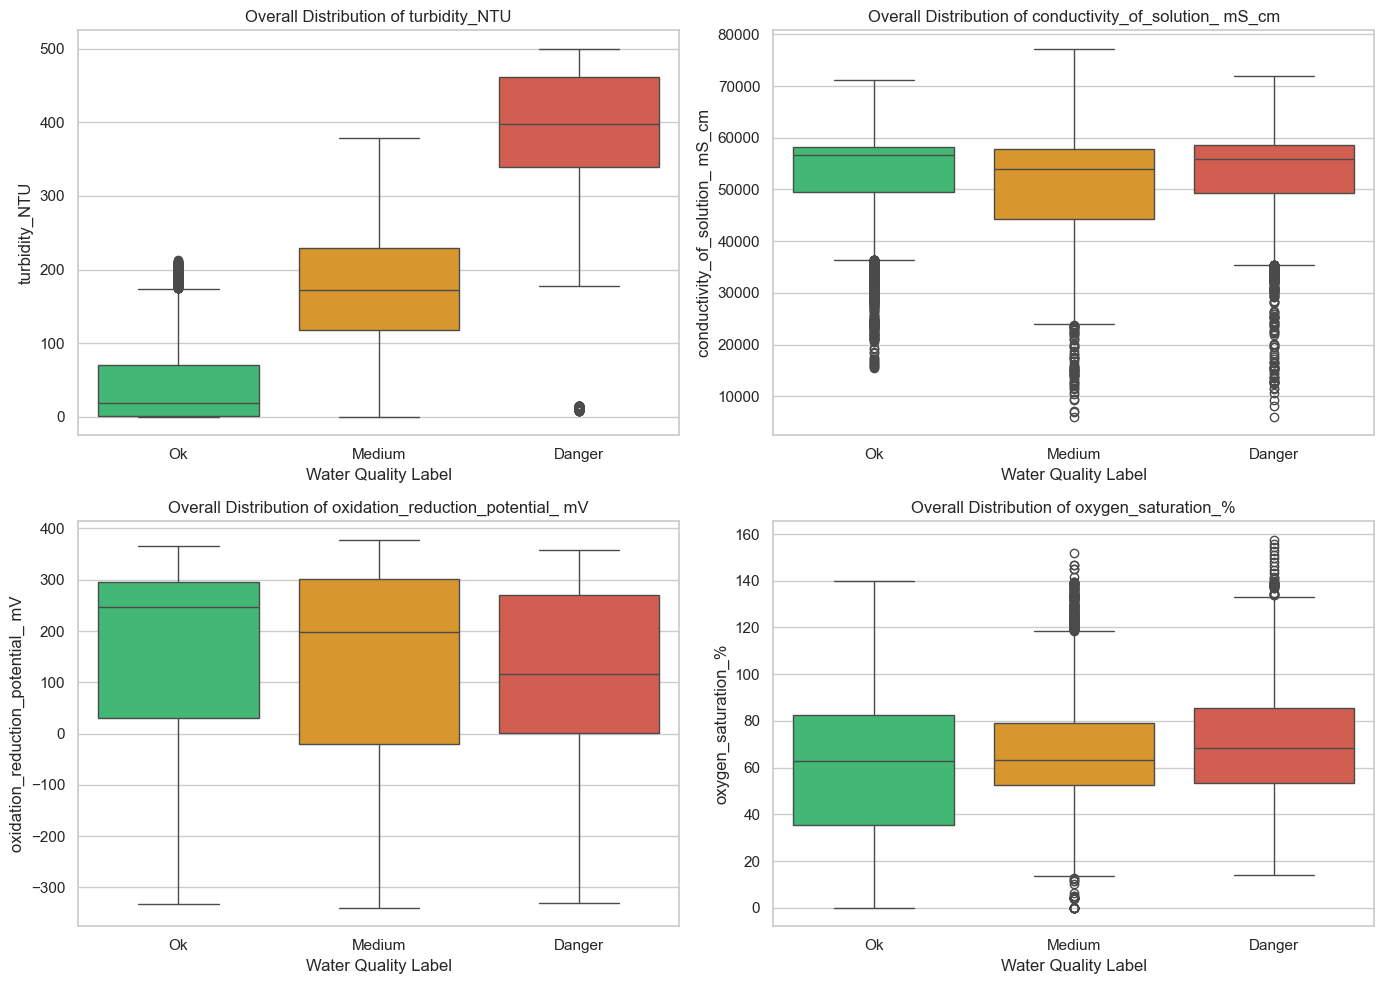

In [7]:
# Set up the plotting style and layout
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Explicitly order the labels on the X-axis for logical scanning
label_order = ['Ok', 'Medium', 'Danger']
palette = {'Ok': '#2ecc71', 'Medium': '#f39c12', 'Danger': '#e74c3c'} # Green, Orange, Red

# List of the 4 original measurement columns to plot
metrics = [
    'turbidity_NTU', 
    'conductivity_of_solution_ mS_cm', 
    'oxidation_reduction_potential_ mV', 
    'oxygen_saturation_%'
]

# Generate a boxplot for each metric
for i, metric in enumerate(metrics):
    sns.boxplot(
        data=final_training_df, 
        x='Water_Quality_Label', 
        y=metric, 
        order=label_order, 
        palette=palette,
        ax=axes[i]
    )
    axes[i].set_title(f'Overall Distribution of {metric}')
    axes[i].set_xlabel('Water Quality Label')
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

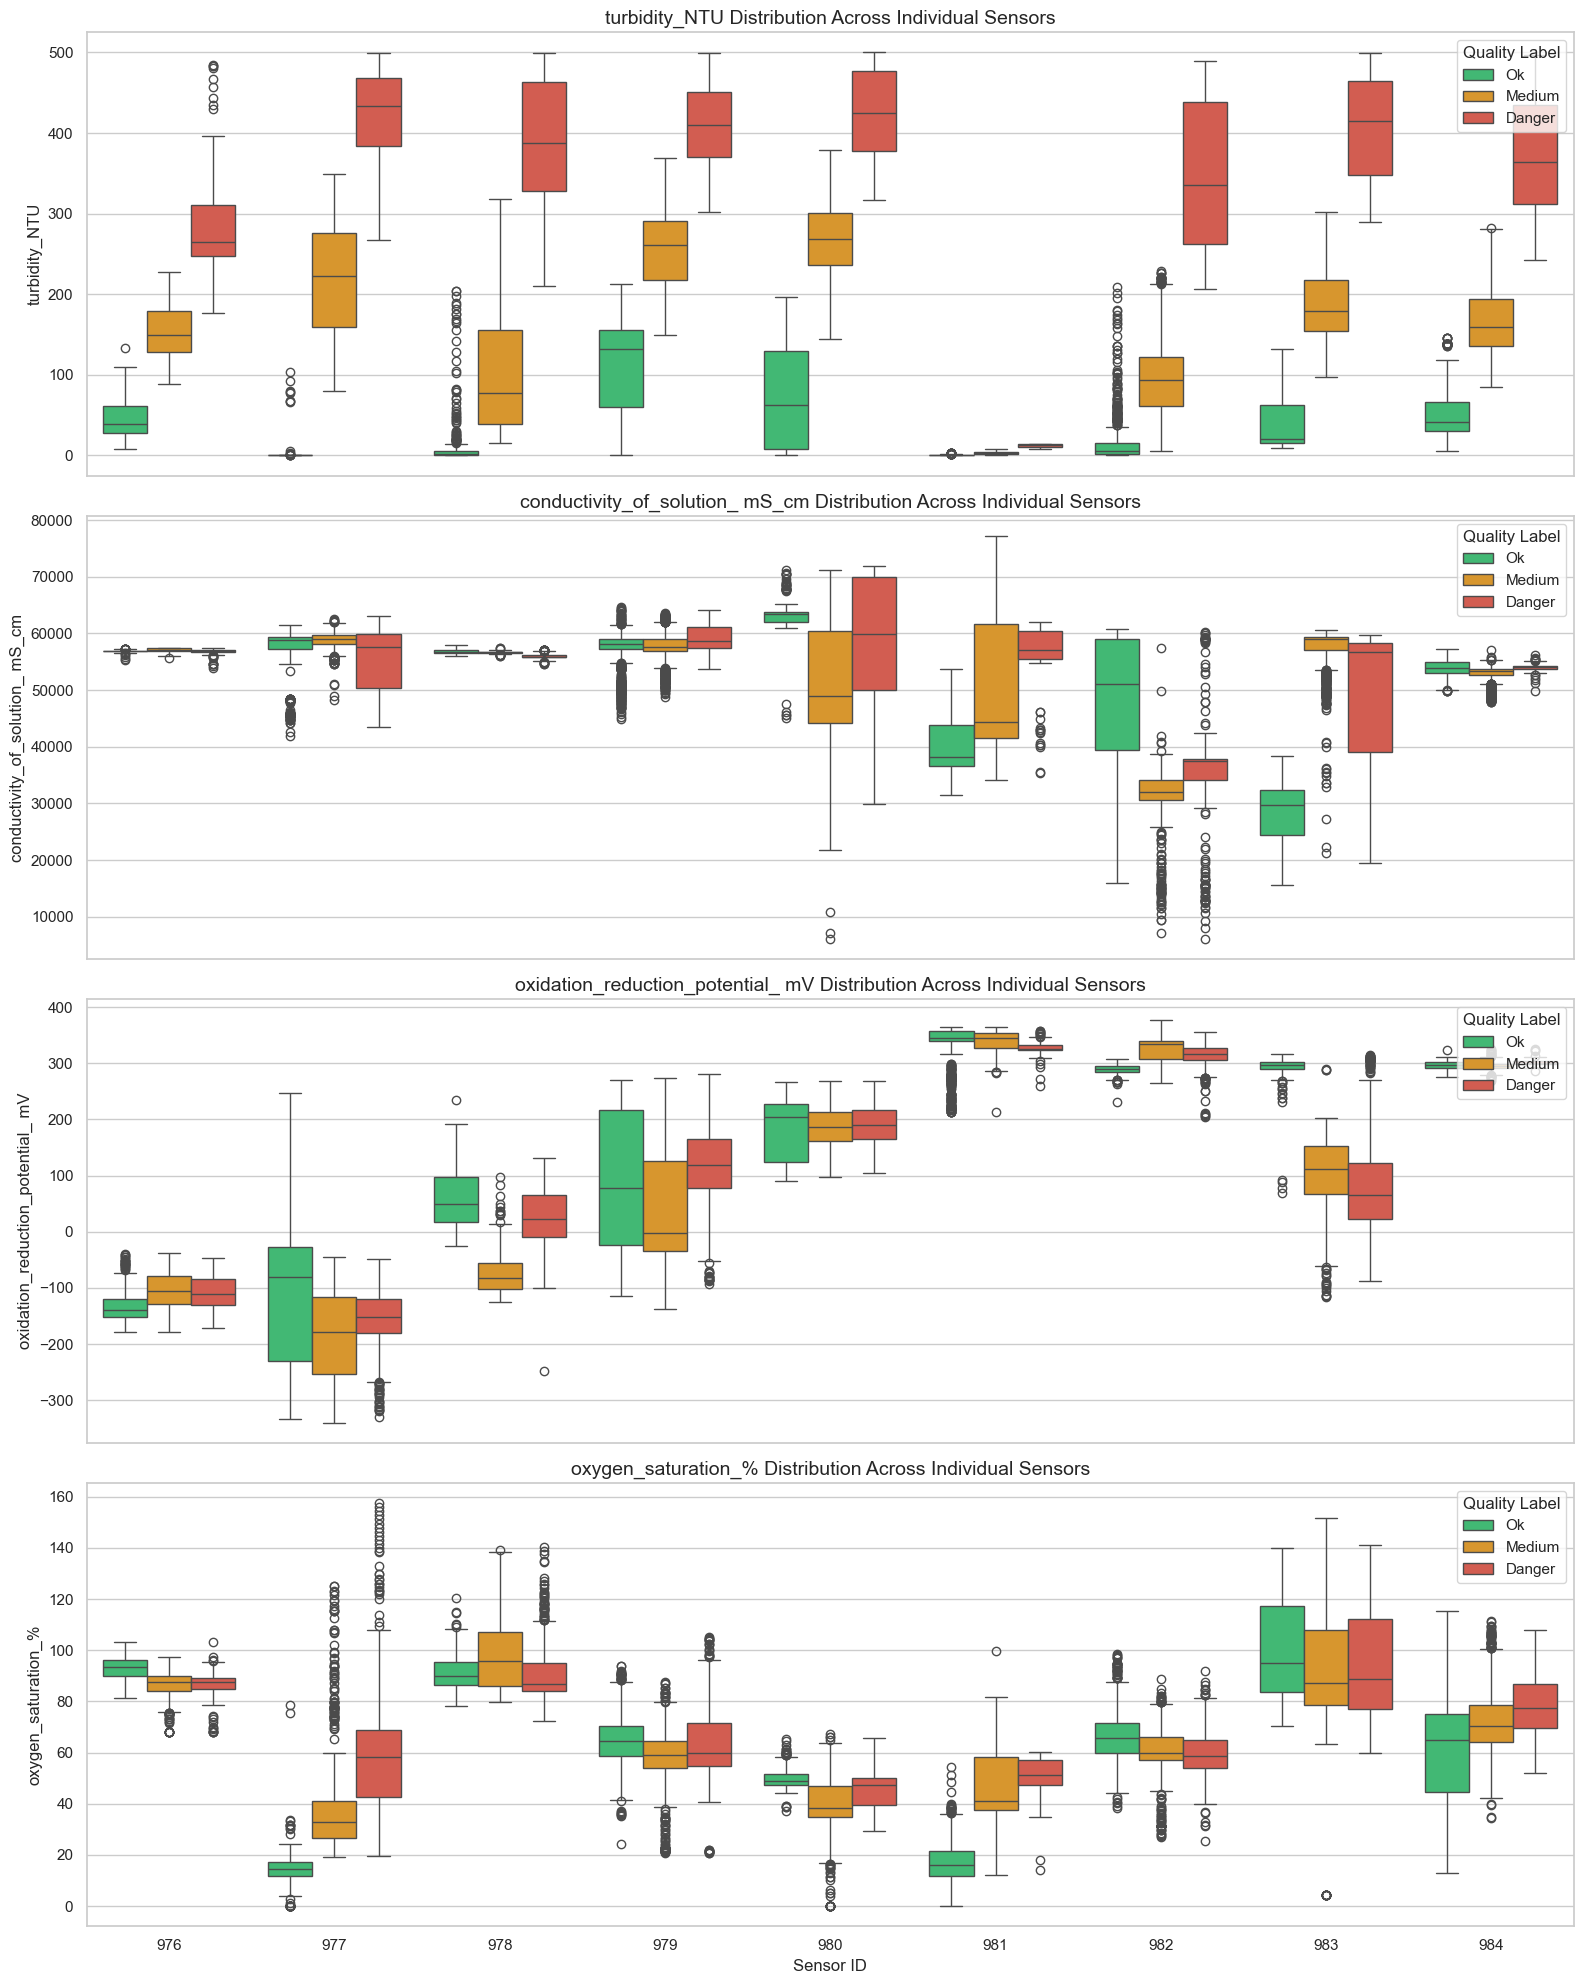

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(16, 20), sharex=True)

# Sort Sensor IDs so the X-axis stays consistently ordered
sensor_order = sorted(final_training_df['sensor_id'].unique())

for i, metric in enumerate(metrics):
    sns.boxplot(
        data=final_training_df,
        x='sensor_id',
        y=metric,
        hue='Water_Quality_Label',
        hue_order=label_order,
        palette=palette,
        order=sensor_order,
        ax=axes[i]
    )
    axes[i].set_title(f'{metric} Distribution Across Individual Sensors', fontsize=14)
    axes[i].set_xlabel('Sensor ID' if i == 3 else '') # Only show label on the bottom plot
    axes[i].set_ylabel(metric, fontsize=12)
    axes[i].legend(title='Quality Label', loc='upper right')

plt.tight_layout()
plt.show()

In [9]:
final_training_df.to_csv(r"C:\Users\User\Desktop\water\data\labeled_water_stats.csv")